In [1]:
from topological_insulator import Problem
import os
print(os.path.exists("../../data/structures/honeycomb.json"))


True


In [2]:
structure_path = "../../data/structures/"
structure_name = "honeycomb.json"


In [3]:
def set_eigenvalues(problem:Problem, t1, t2, M_val, B):
    problem.cell_parser.field.magnetic.value = B
    sublattice_labels = ["A", "B", "C", "D", "E", "F"]
    cell = problem.cell_parser
    g = cell.geometry
    n_subs = len(g.delta_vectors.value)
    subs = sublattice_labels[:n_subs]
    for label_i in subs:
        parser = getattr(problem.cell_parser.eigenvalues, label_i).value
        M = lambda label: M_val if label == "A" else -M_val
        parser["onsite_energy"][label_i]["E_s"] = M(label_i)
        for label_j in subs:
            # Hoppings
            try:
                parser["nn_hopping"][label_j]["t_ss_sigma"] = t1
            except:
                pass
            # Spin-Orbit Coupling
            try:
                parser["kane_mele_soc"][label_j]["lambda_ss"] = t2
            except:
                pass

In [4]:
location = "bulk"
B = 0
t_1 = -1

In [5]:
cases = {
    0: {"t_2": 0.07*t_1, "M": 0},
    1: {"t_2": 0, "M": 0.25*abs(t_1)},
}

In [6]:
results = {}
for n, eigenvalue_dict in enumerate(cases.values()):
    t_2 = eigenvalue_dict["t_2"]
    M = eigenvalue_dict["M"]
    print("")
    print(f"Running case for: t_2 = {t_2} and |M| = {M}")
    problem = Problem(structure_path=structure_path, structure_name=structure_name)
    set_eigenvalues(problem, t_1, t_2, M, B)
    problem.setup(
        N_r = 10,
        N_k = 500,
        location = location,
        BZ = "reduced"
    )
    problem.run(
        H_type="reciprocal"
    )
    results[n] = problem


Running case for: t_2 = -0.07 and |M| = 0
Building Geometry...
Geometry - Done.
Building 'Bulk' Hamiltonian...
'Bulk' Hamiltonian - Done.
Calculating 'Bulk' Eigenvalues...
'Bulk' Eigenvalues - Done!

Running case for: t_2 = 0 and |M| = 0.25
Building Geometry...
Geometry - Done.
Building 'Bulk' Hamiltonian...
'Bulk' Hamiltonian - Done.
Calculating 'Bulk' Eigenvalues...
'Bulk' Eigenvalues - Done!


In [7]:
bands = [0, 1] # degenerate

## Case 0

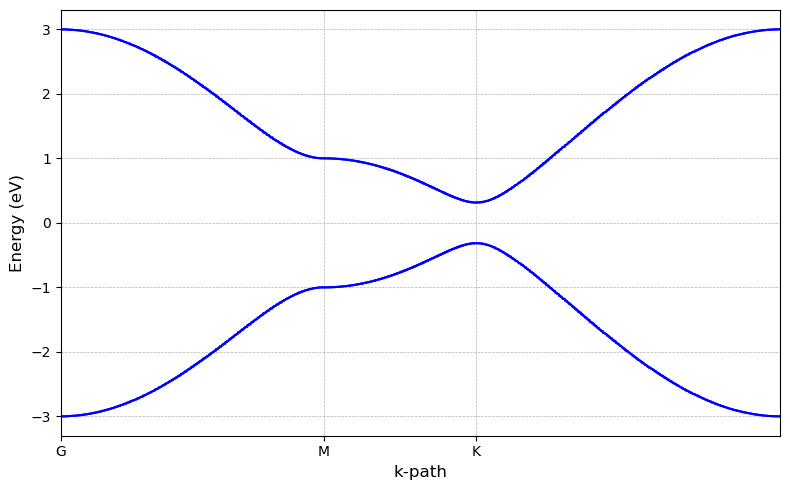

In [8]:
results[0].plot("high_symmetry", location=location)

In [9]:
if results[0].cell_parser.field.magnetic.value != 0:
    C, F  = results[0].get_topological_invariant(bands=bands)
    print(f"Chern Invariant: {round(C/3)}")
    results[0].plot("berry_flux", location=location, F=F)
else:
    Z2 = results[0].get_topological_invariant(bands=bands)
    print(f"Z2 Invariant: {Z2}")

Calculating Z2 Invariant...
Z2 Invariant - Done!
Z2 Invariant: 0


/opt/anaconda3/lib/python3.12/site-packages/numpy/linalg/linalg.py:2180: RuntimeWarning: divide by zero encountered in det
  r = _umath_linalg.det(a, signature=signature)
/opt/anaconda3/lib/python3.12/site-packages/numpy/linalg/linalg.py:2180: RuntimeWarning: invalid value encountered in det
  r = _umath_linalg.det(a, signature=signature)


## Case 1

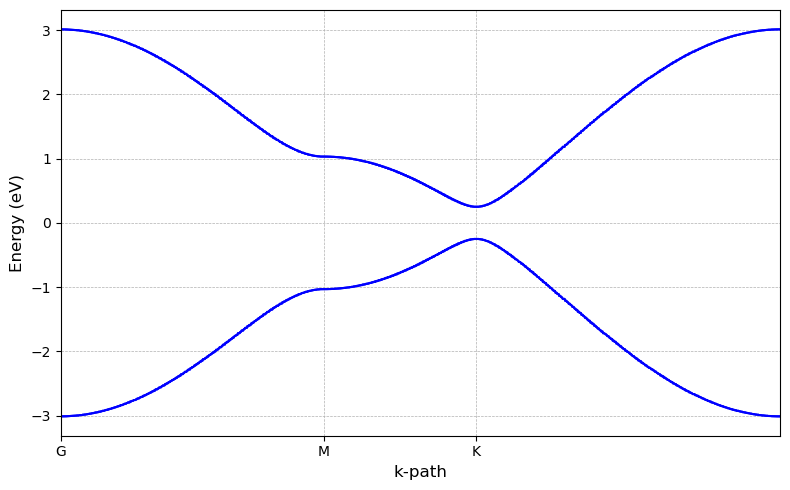

In [10]:
results[1].plot("high_symmetry", location=location, hide=True)

In [11]:
if results[1].cell_parser.field.magnetic.value != 0:
    C, F = results[1].get_topological_invariant(bands=bands)
    print(f"Chern Invariant: {round(C/3)}")
    results[1].plot("berry_flux", location=location, F=F)
else:
    Z2 = results[1].get_topological_invariant(bands=bands)
    print(f"Z2 Invariant: {Z2}")

Calculating Z2 Invariant...
Z2 Invariant - Done!
Z2 Invariant: 0


/opt/anaconda3/lib/python3.12/site-packages/numpy/linalg/linalg.py:2180: RuntimeWarning: divide by zero encountered in det
  r = _umath_linalg.det(a, signature=signature)
/opt/anaconda3/lib/python3.12/site-packages/numpy/linalg/linalg.py:2180: RuntimeWarning: invalid value encountered in det
  r = _umath_linalg.det(a, signature=signature)
